In [25]:
import pandas as pd
import numpy as np

In [26]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Drop ID
data.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].mean())

# One Hot Encoding
data = pd.get_dummies(data, drop_first=True)

print("Final Shape:", data.shape)

Final Shape: (7043, 31)


In [27]:
X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

print("Balanced model trained!")

Balanced model trained!


In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7473385379701917

Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.72      0.81      1036
        True       0.51      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


Confusion Matrix:
 [[746 290]
 [ 66 307]]


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [35]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7927608232789212

Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.92      0.87      1036
        True       0.66      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
 [[950  86]
 [206 167]]


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7913413768630234

Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.79      0.85      1036
        True       0.58      0.78      0.67       373

    accuracy                           0.79      1409
   macro avg       0.74      0.79      0.76      1409
weighted avg       0.82      0.79      0.80      1409


Confusion Matrix:
 [[823 213]
 [ 81 292]]


In [39]:
!pip install matplotlib


  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 9.9 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 11.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.0 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 12.4 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


                           Feature  Importance
1                           tenure    0.177343
3                     TotalCharges    0.144693
25               Contract_Two year    0.105397
2                   MonthlyCharges    0.102075
10     InternetService_Fiber optic    0.067234
28  PaymentMethod_Electronic check    0.053140
24               Contract_One year    0.041636
13              OnlineSecurity_Yes    0.032861
19                 TechSupport_Yes    0.025554
26            PaperlessBilling_Yes    0.018888


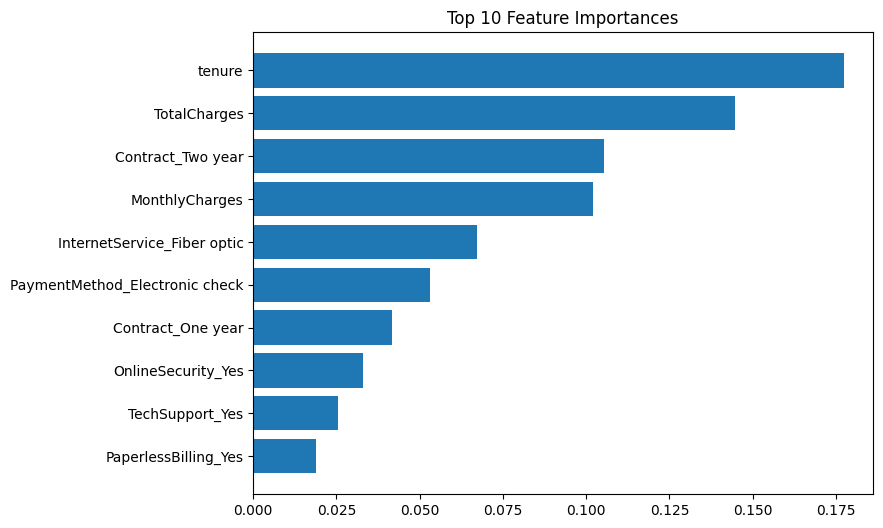

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_df.head(10))

plt.figure(figsize=(8,6))
plt.barh(feature_df["Feature"][:10], feature_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

In [41]:

import joblib

joblib.dump(rf_model, "churn_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")

Model saved successfully!


AUC Score: 0.8631193909344044


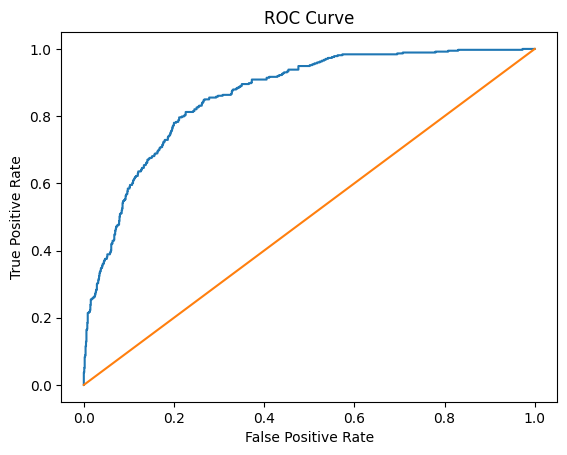

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
y_probs = rf_model.predict_proba(X_test)[:,1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print("AUC Score:", auc_score)

# Plot
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [44]:
X_test[0].tolist()

[-0.43774920386247823,
 -1.2846046672683313,
 -1.3316287386429382,
 -1.0023881693233978,
 -1.0251656884383933,
 1.0313759080646898,
 -0.6526623241304862,
 -3.034225064020537,
 3.034225064020537,
 -0.860523365976793,
 -0.8870567332219115,
 -0.5240807509193244,
 -0.5240807509193244,
 -0.6325341125809174,
 -0.5240807509193244,
 -0.7338280111665758,
 -0.5240807509193244,
 -0.7221281597646181,
 -0.5240807509193244,
 -0.6377629442306191,
 -0.5240807509193244,
 -0.7947481828833275,
 -0.5240807509193244,
 -0.7995125078560146,
 -0.523530443078904,
 -0.5583528077966375,
 0.8333283207869295,
 -0.5276558483992174,
 1.4091456893901597,
 -0.5427496714714372]